# Mahalanobis Distance to SHAP Vectors of Current Round

In [73]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from sklearn.metrics import confusion_matrix
from matplotlib.lines import Line2D

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

RUN_NAME = "fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_mpaf_lambda0.3"
RUN_NAME = (
    "fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_label_flip_pf0.5_v1_t0"
)
BASE_PATH = Path("../experiments/shap_outputs") / RUN_NAME

CUSUM_K = 0.5  # slack: allowance before accumulation starts (in units of round std)
CUSUM_H = 3.0  # threshold: flag when cumulative sum exceeds this

print(f"Run      : {RUN_NAME}")
print(f"Path     : {BASE_PATH}")
print(f"CUSUM k  : {CUSUM_K}  |  CUSUM h : {CUSUM_H}")

Run      : fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_label_flip_pf0.5_v1_t0
Path     : ../experiments/shap_outputs/fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_label_flip_pf0.5_v1_t0
CUSUM k  : 0.5  |  CUSUM h : 3.0


In [74]:
# ── Loaders & distance functions ───────────────────────────────────────────────


def load_json(path):
    try:
        with open(path) as f:
            return json.load(f)
    except Exception:
        return {}


def load_npz_vector(path):
    """Load first array from .npz and reduce to a 1-D per-feature vector."""
    try:
        z = np.load(path, allow_pickle=True)
        arr = np.asarray(z[list(z.keys())[0]])
        if arr.ndim == 0:
            return np.array([float(arr)])
        if arr.ndim == 1:
            return arr
        return np.mean(arr, axis=0)  # (n_samples, n_features) -> (n_features,)
    except Exception:
        return None


def round_median(vectors):
    """Compute the coordinate-wise median SHAP vector for a round."""
    return np.median(np.vstack(vectors), axis=0)


# metadata
# source

client_data = defaultdict(dict)
round_dirs = sorted(
    [d for d in BASE_PATH.iterdir() if d.is_dir() and d.name.startswith("round_")]
)

print(f"Found {len(round_dirs)} rounds.")

for rdir in round_dirs:
    rnum = int(rdir.name.split("_")[1])
    for cdir in sorted([d for d in rdir.iterdir() if d.is_dir()]):
        cid = cdir.name
        meta = load_json(cdir / "metadata.json")
        sv = load_npz_vector(cdir / "shap_values.npz")
        if sv is None:
            continue
        if cid not in client_data:
            client_data[cid] = {
                "is_malicious": bool(
                    meta.get("malicious", meta.get("is_malicious", False))
                ),
                "rounds": {},
            }
        client_data[cid]["rounds"][rnum] = sv

n_mal = sum(1 for c in client_data.values() if c["is_malicious"])
n_ben = sum(1 for c in client_data.values() if not c["is_malicious"])
print(f"Clients loaded : {len(client_data)}  |  malicious: {n_mal}  |  benign: {n_ben}")

Found 30 rounds.
Clients loaded : 30  |  malicious: 6  |  benign: 24


In [75]:


def mahalanobis_distance(x, mean, cov=None, cov_inv=None, reg=1e-6):
    """
    Mahalanobis distance between 1-D vector `x` and `mean`.
    Provide either `cov_inv` (inverse covariance) or `cov` (covariance matrix).
    `reg` is a small diagonal regularizer for numerical stability.

    Returns:
        float
    """
    x = np.asarray(x, dtype=float)
    mean = np.asarray(mean, dtype=float)
    delta = x - mean

    if cov_inv is None:
        if cov is None:
            # fallback: can't compute Mahalanobis without covariance info
            return float(np.linalg.norm(delta))
        cov = np.asarray(cov, dtype=float)
        cov_inv = np.linalg.pinv(cov + reg * np.eye(cov.shape[0]))

    try:
        dist2 = float(np.dot(delta, cov_inv.dot(delta)))
        return float(np.sqrt(max(dist2, 0.0)))
    except Exception:
        return float(np.linalg.norm(delta))

In [76]:
all_rounds = sorted({r for c in client_data.values() for r in c["rounds"]})
records = []

for rnum in all_rounds:
    vectors_this_round = {
        cid: cinfo["rounds"][rnum]
        for cid, cinfo in client_data.items()
        if rnum in cinfo["rounds"]
    }
    if len(vectors_this_round) < 3:
        continue

    round_center = round_median(list(vectors_this_round.values()))

    vals = np.vstack(list(vectors_this_round.values()))
    try:
        cov = np.cov(vals, rowvar=False)
        cov_inv = np.linalg.pinv(cov + 1e-6 * np.eye(cov.shape[0]))
    except Exception:
        cov_inv = np.linalg.pinv(
            np.cov(vals, rowvar=False) + 1e-6 * np.eye(vals.shape[1])
        )

    for cid, sv in vectors_this_round.items():
        records.append(
            {
                "round": rnum,
                "client": cid,
                "is_malicious": client_data[cid]["is_malicious"],
                "mahalanobis_distance": mahalanobis_distance(
                    sv, round_center, cov_inv=cov_inv
                ),
            }
        )

df = pd.DataFrame(records)
print(
    f"Score table: {len(df)} rows  |  rounds: {df['round'].nunique()}  |  clients: {df['client'].nunique()}"
)
print()
print(df.groupby("is_malicious")["mahalanobis_distance"].describe().T)

Score table: 900 rows  |  rounds: 30  |  clients: 30

is_malicious       False       True 
count         720.000000  180.000000
mean            5.103114    4.888409
std             0.441121    0.501313
min             3.285112    3.225644
25%             4.832865    4.567540
50%             5.116650    4.885432
75%             5.363670    5.225022
max             6.720061    6.222190


In [77]:
# # ── Optional z-score flagging ──────────────────────────────────────────────────
# round_stats = (
#     df.groupby('round')['mahalanobis_distance']
#     .agg(['mean', 'std'])
#     .rename(columns={'mean': 'dist_mu', 'std': 'dist_sigma'})
#     .reset_index()
# )
#
# df = df.merge(round_stats, on='round')
# df['flagged'] = df['mahalanobis_distance'] > (df['dist_mu'] + 2.0 * df['dist_sigma'])
#
# print("Per-round flag counts:")
# print(df.groupby('round')['flagged'].sum().rename('n_flagged').to_frame())


In [78]:
# ── CUSUM flagging on Mahalanobis distance ─────────────────────────────────────
# Standardise per round, then accumulate excess above slack k across rounds.
# S_i^t = max(0, S_i^{t-1} + (x_i^t - mu_t) / sigma_t - k)
# Flag client i at round t if S_i^t > h.

round_stats = (
    df.groupby("round")["mahalanobis_distance"]
    .agg(dist_mu="mean", dist_sigma="std")
    .reset_index()
)
round_stats["dist_sigma"] = round_stats["dist_sigma"].fillna(1.0)
df = df.merge(round_stats, on="round")
df["dist_excess"] = (df["mahalanobis_distance"] - df["dist_mu"]) / df["dist_sigma"]

# Run CUSUM per client across rounds in order
cusum_records = []
for cid, cdf in df.groupby("client"):
    cdf = cdf.sort_values("round")
    S = 0.0
    for _, row in cdf.iterrows():
        S = max(0.0, S + row["dist_excess"] - CUSUM_K)
        cusum_records.append(
            {
                "round": row["round"],
                "client": cid,
                "cusum": S,
                "flagged": S > CUSUM_H,
            }
        )

cusum_df = pd.DataFrame(cusum_records)
df = df.merge(cusum_df[["round", "client", "cusum", "flagged"]], on=["round", "client"])

print("Per-round flag counts:")
print(df.groupby("round")["flagged"].sum().rename("n_flagged").to_frame())

TOP_K = 3
topk_per_round = (
    df.sort_values(["round", "cusum"], ascending=[True, False])
    .groupby("round")
    .head(TOP_K)
    .loc[
        :,
        ["round", "client", "is_malicious", "mahalanobis_distance", "cusum", "flagged"],
    ]
)
print(f"\nTop-{TOP_K} suspicious clients per round (by CUSUM):")
print(topk_per_round.to_string(index=False))

Per-round flag counts:
       n_flagged
round           
1              0
2              0
3              0
4              0
5              0
6              1
7              1
8              2
9              2
10             2
11             3
12             2
13             2
14             2
15             1
16             3
17             2
18             3
19             3
20             3
21             3
22             2
23             3
24             3
25             3
26             2
27             2
28             2
29             3
30             2

Top-3 suspicious clients per round (by CUSUM):
 round    client  is_malicious  mahalanobis_distance     cusum  flagged
     1 client_24          True              5.383226  0.692533    False
     1 client_20         False              5.337952  0.609895    False
     1  client_5         False              5.320478  0.577999    False
     2 client_12         False              5.498241  1.311475    False
     2 client_14         

## Score Visualisation

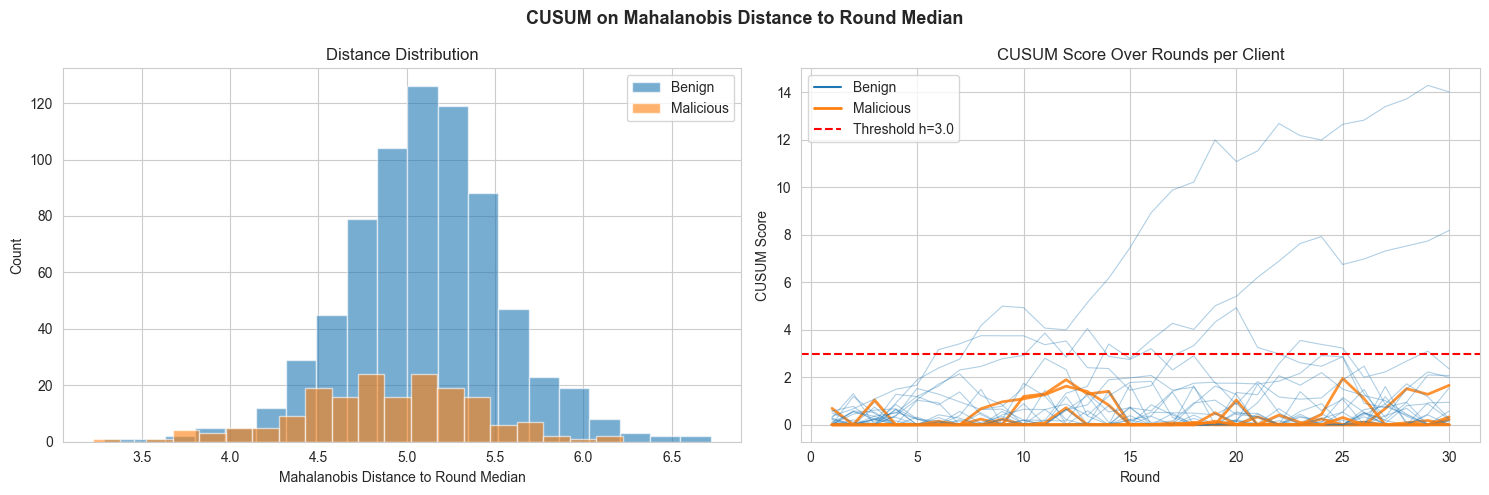

In [79]:
# ── Distribution + CUSUM trajectory over rounds ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for label, grp in df.groupby("is_malicious"):
    color = "tab:orange" if label else "tab:blue"
    name = "Malicious" if label else "Benign"
    ax.hist(
        grp["mahalanobis_distance"],
        bins=20,
        alpha=0.6,
        color=color,
        label=name,
        edgecolor="white",
    )
ax.set_xlabel("Mahalanobis Distance to Round Median")
ax.set_ylabel("Count")
ax.set_title("Distance Distribution")
ax.legend()

ax = axes[1]
for cid, grp in df.groupby("client"):
    is_mal = grp["is_malicious"].iloc[0]
    color = "tab:orange" if is_mal else "tab:blue"
    alpha = 0.85 if is_mal else 0.35
    lw = 2.0 if is_mal else 0.8
    ax.plot(grp["round"], grp["cusum"], color=color, alpha=alpha, linewidth=lw)

ax.axhline(
    CUSUM_H, color="red", linestyle="--", linewidth=1.5, label=f"Threshold h={CUSUM_H}"
)
legend_elements = [
    Line2D([0], [0], color="tab:blue", linewidth=1.5, label="Benign"),
    Line2D([0], [0], color="tab:orange", linewidth=2.0, label="Malicious"),
    Line2D(
        [0],
        [0],
        color="red",
        linewidth=1.5,
        linestyle="--",
        label=f"Threshold h={CUSUM_H}",
    ),
]
ax.legend(handles=legend_elements)
ax.set_xlabel("Round")
ax.set_ylabel("CUSUM Score")
ax.set_title("CUSUM Score Over Rounds per Client")

plt.suptitle(
    "CUSUM on Mahalanobis Distance to Round Median", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_10124/1922500378.py:34: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  plt.tight_layout()
/home/b-fatma/miniconda3/envs/flwr/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


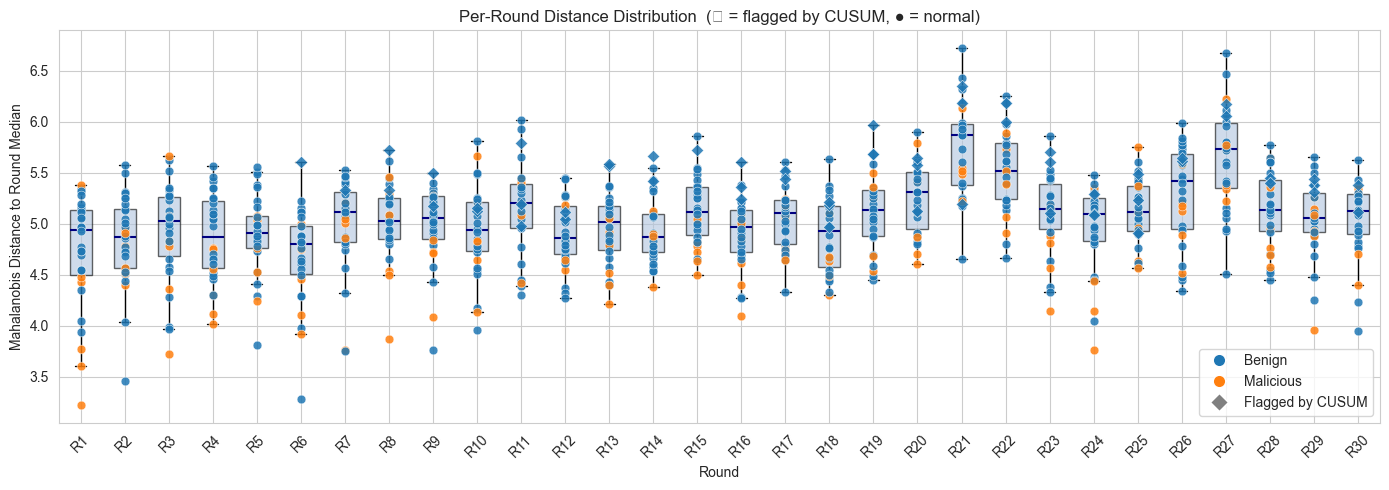

In [80]:
# ── Per-round box plot: Mahalanobis distance with flagged points highlighted ────
fig, ax = plt.subplots(figsize=(14, 5))

round_order = sorted(df["round"].unique())
positions = list(range(len(round_order)))
round_groups = [
    df[df["round"] == r]["mahalanobis_distance"].values for r in round_order
]

ax.boxplot(
    round_groups,
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="lightsteelblue", alpha=0.6),
    medianprops=dict(color="navy", linewidth=1.5),
)

for pos, rnum in zip(positions, round_order):
    rdf = df[df["round"] == rnum]
    for _, row in rdf.iterrows():
        color = "tab:orange" if row["is_malicious"] else "tab:blue"
        marker = "D" if row["flagged"] else "o"
        zorder = 5 if row["flagged"] else 3
        ax.scatter(
            pos,
            row["mahalanobis_distance"],
            color=color,
            s=40,
            marker=marker,
            zorder=zorder,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.4,
        )

ax.set_xticks(positions)
ax.set_xticklabels([f"R{r}" for r in round_order], rotation=45)
ax.set_xlabel("Round")
ax.set_ylabel("Mahalanobis Distance to Round Median")
ax.set_title("Per-Round Distance Distribution  (◇ = flagged by CUSUM, ● = normal)")

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="tab:blue",
        markersize=9,
        label="Benign",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="tab:orange",
        markersize=9,
        label="Malicious",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        color="w",
        markerfacecolor="grey",
        markersize=9,
        label="Flagged by CUSUM",
    ),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

In [81]:
# Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = df["is_malicious"].astype(int)
y_pred = df["flagged"].astype(int)

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print("=" * 40)
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print("-" * 40)
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("=" * 40)

  TP=0  FP=57  FN=180  TN=663
----------------------------------------
  Precision : 0.0000
  Recall    : 0.0000
  F1 Score  : 0.0000
